# NHL Salary Prediction — EDA

## Часть 1. Первичный анализ сырых данных

Цель этого раздела - понять структуру данных, распределение целевой переменной
и характер пропусков. На основе наблюдений принимаются решения по очистке
и трансформациям в `src/preprocessing.py`.

## 0. Источники данных

Данные собраны из трёх источников:

| Источник | Что содержит | Метод сбора |
|---|---|---|
| NHL Stats API (`api.nhle.com`) | Игровая статистика, биография | `requests` |
| NHL Web API (`api-web.nhle.com`) | Рост, вес, драфт | `requests` |
| Spotrac (`spotrac.com`) | Cap hit — зарплата против потолка | `Selenium` |

**Почему эти источники:**
- NHL Stats API - официальный источник статистики, бесплатный, полный охват сезонов
- Spotrac - наиболее полная база контрактов NHL, включает точный cap hit по каждому сезону
- Данные объединены по нормализованному имени игрока (`name_key`)

**Сезоны:** 2021-22 → 2025-26 (только регулярный сезон)  
**Единица наблюдения:** один игрок в одном сезоне

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

root = Path("..") 

sk = pd.read_csv(root / "data" / "raw" / "nhl_skaters_raw.csv")
go = pd.read_csv(root / "data" / "raw" / "nhl_goalies_raw.csv")

print("Скейтеры:", sk.shape)
print("Вратари:  ", go.shape)
print("\nСезоны скейтеры:", sorted(sk["season_year"].unique()))
print("Сезоны вратари: ", sorted(go["season_year"].unique()))

Скейтеры: (4748, 90)
Вратари:   (525, 46)

Сезоны скейтеры: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Сезоны вратари:  [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


### Результат

- Скейтеры: **4748 строк × 90 колонок** - 5 сезонов, около 900-1000 игроков в среднем за сезон
- Вратари: **525 строк × 46 колонок** - вратарей значительно меньше, это ожидаемо 
- Единица наблюдения: один игрок в одном сезоне, то есть один игрок может встречаться до 5 раз

In [7]:
print("Колонки скейтеров по группам:")
print()

groups = {
    "Идентификация": ["playerId", "skaterFullName", "lastName", "positionCode",
                      "shootsCatches", "teamAbbrevs", "season", "season_year"],
    "Базовая статистика": ["gamesPlayed", "goals", "assists", "points", "pointsPerGame",
                           "plusMinus", "penaltyMinutes", "shots", "shootingPct",
                           "timeOnIcePerGame"],
    "Realtime": ["hits", "blockedShots", "giveaways", "takeaways", "totalShotAttempts"],
    "Большинство": [c for c in sk.columns if c.startswith("pp")],
    "Вбрасывания": [c for c in sk.columns if "aceoff" in c],
    "Биография": ["heightInInches", "weightInPounds", "birthCountry",
                  "draftYear", "draftRound", "draftOverall"],
    "Таргет (Spotrac)": ["cap_hit"],
}

for group, cols in groups.items():
    existing = [c for c in cols if c in sk.columns]
    print(f"{group} ({len(existing)} колонок): {existing}")
    print()

Колонки скейтеров по группам:

Идентификация (8 колонок): ['playerId', 'skaterFullName', 'lastName', 'positionCode', 'shootsCatches', 'teamAbbrevs', 'season', 'season_year']

Базовая статистика (10 колонок): ['gamesPlayed', 'goals', 'assists', 'points', 'pointsPerGame', 'plusMinus', 'penaltyMinutes', 'shots', 'shootingPct', 'timeOnIcePerGame']

Realtime (5 колонок): ['hits', 'blockedShots', 'giveaways', 'takeaways', 'totalShotAttempts']

Большинство (20 колонок): ['ppGoals', 'ppPoints', 'ppFaceoffPct', 'ppFaceoffs', 'ppAssists', 'ppGoalsForPer60', 'ppGoalsPer60', 'ppIndividualSatFor', 'ppIndividualSatForPer60', 'ppPointsPer60', 'ppPrimaryAssists', 'ppPrimaryAssistsPer60', 'ppSecondaryAssists', 'ppSecondaryAssistsPer60', 'ppShootingPct', 'ppShots', 'ppShotsPer60', 'ppTimeOnIce', 'ppTimeOnIcePctPerGame', 'ppTimeOnIcePerGame']

Вбрасывания (14 колонок): ['faceoffWinPct', 'defensiveZoneFaceoffPct', 'defensiveZoneFaceoffs', 'evFaceoffPct', 'evFaceoffs', 'neutralZoneFaceoffPct', 'neutralZone

### Структура колонок скейтеров (90 всего)

| Группа | Колонок | Примечание |
|---|---|---|
| Идентификация | 8 | ID, имя, позиция, команда, сезон |
| Базовая статистика | 10 | Голы, передачи, очки, время на льду |
| Realtime | 5 | Хиты, блоки, Corsi |
| Большинство | 20 | Детальная статистика игры в большинстве |
| Вбрасывания | 14 | По зонам и составам |
| Биография | 6 | Рост, вес, драфт |
| Прочие | 26 | Меньшинство, пустые ворота, промахи и др. |
| Таргет | 1 | `cap_hit` - зарплата против потолка |

Группы "Большинство" и "Вбрасывания" содержат много взаимокоррелирующих колонок,
на этапе моделирования потребуется отбор признаков или уменьшение размерности.

In [9]:
print("Типы данных скейтеры:")
print(sk.dtypes.value_counts())
print()

object_cols = sk.select_dtypes(include="str").columns.tolist()
print("Строковые колонки:", object_cols)
print()

print("Типы данных вратари:")
print(go.dtypes.value_counts())
print()

object_cols_go = go.select_dtypes(include="str").columns.tolist()
print("Строковые колонки:", object_cols_go)

Типы данных скейтеры:
int64      45
float64    34
str        11
Name: count, dtype: int64

Строковые колонки: ['lastName', 'positionCode', 'shootsCatches', 'skaterFullName', 'teamAbbrevs', 'name_key', 'birthCity', 'birthCountry', 'player_name_cw', 'team_cw', 'position_cw']

Типы данных вратари:
int64      26
str        10
float64    10
Name: count, dtype: int64

Строковые колонки: ['goalieFullName', 'lastName', 'shootsCatches', 'teamAbbrevs', 'name_key', 'birthCity', 'birthCountry', 'player_name_cw', 'team_cw', 'position_cw']


### Типы данных

**Скейтеры:** 45 int64, 34 float64, 11 строковых  
**Вратари:** 26 int64, 10 float64, 10 строковых

Строковые колонки делятся на две группы:

- **Нужны для модели после кодирования:** `positionCode`, `shootsCatches`, `birthCountry`
- **Служебные / leakage — будут удалены в preprocessing:** `name_key`, `player_name_cw`, `team_cw`, `position_cw`
- **Не используются в модели:** `skaterFullName`, `lastName`, `birthCity`, `teamAbbrevs` (заменится флагом `is_multi_team`)

In [10]:
print("Дубликаты скейтеры:")
full_dupes_sk = sk.duplicated().sum()
player_season_dupes_sk = sk.duplicated(subset=["playerId", "season_year"]).sum()
print(f"  Полных дублей: {full_dupes_sk}")
print(f"  Дублей по (playerId, season_year): {player_season_dupes_sk}")

print()
print("Дубликаты вратари:")
full_dupes_go = go.duplicated().sum()
player_season_dupes_go = go.duplicated(subset=["playerId", "season_year"]).sum()
print(f"  Полных дублей: {full_dupes_go}")
print(f"  Дублей по (playerId, season_year): {player_season_dupes_go}")

print()
print("Уникальных игроков скейтеры:", sk["playerId"].nunique())
print("Уникальных игроков вратари: ", go["playerId"].nunique())
print()
print("Среднее сезонов на игрока скейтеры:", round(len(sk) / sk["playerId"].nunique(), 2))
print("Среднее сезонов на игрока вратари: ", round(len(go) / go["playerId"].nunique(), 2))

Дубликаты скейтеры:
  Полных дублей: 0
  Дублей по (playerId, season_year): 9

Дубликаты вратари:
  Полных дублей: 0
  Дублей по (playerId, season_year): 0

Уникальных игроков скейтеры: 1481
Уникальных игроков вратари:  174

Среднее сезонов на игрока скейтеры: 3.21
Среднее сезонов на игрока вратари:  3.02


### Дубликаты

Полных дублей нет ни у скейтеров, ни у вратарей.

У скейтеров обнаружено **9 дублей по (playerId, season_year)** - это игроки,
которые за один сезон сменили команду и попали в датасет дважды. В preprocessing они будут схлопнуты в одну строку.

**Уникальных игроков:** 1481 скейтер, 174 вратаря  
**Среднее сезонов на игрока:** ~3.2 - большинство игроков присутствует в 3-4 сезонах из 5.

In [11]:
print("cap_hit скейтеры")
print(sk["cap_hit"].describe().round(0))
print(f"\nПропусков: {sk['cap_hit'].isna().sum()} ({sk['cap_hit'].isna().mean():.1%})")
print(f"Скошенность (skew): {sk['cap_hit'].skew():.2f}")

print()
print("cap_hit вратари")
print(go["cap_hit"].describe().round(0))
print(f"\nПропусков: {go['cap_hit'].isna().sum()} ({go['cap_hit'].isna().mean():.1%})")
print(f"Скошенность (skew): {go['cap_hit'].skew():.2f}")

cap_hit скейтеры
count        3128.0
mean      3593544.0
std       2868904.0
min        224000.0
25%        925000.0
50%       2900000.0
75%       5500000.0
max      17000000.0
Name: cap_hit, dtype: float64

Пропусков: 1620 (34.1%)
Скошенность (skew): 0.90

cap_hit вратари
count         319.0
mean      3346816.0
std       2511772.0
min        733333.0
25%       1000000.0
50%       2750000.0
75%       5000000.0
max      11500000.0
Name: cap_hit, dtype: float64

Пропусков: 206 (39.2%)
Скошенность (skew): 0.99


### Целевая переменная - cap_hit

|  | Скейтеры | Вратари |
|---|---|---|
| Записей с зарплатой | 3128 | 319 |
| Пропусков | 1620 (34.1%) | 206 (39.2%) |
| Минимум | 224 000 | 733 333 |
| Медиана | 2 900 000 | 2 750 000 |
| Максимум | 17 000 000 | 11 500 000 |
| Скошенность | 0.90 | 0.99 |

Распределение умеренно скошено вправо,
большинство игроков получают около медианы, но есть хвост из топ-игроков
с контрактами 10M+. Логарифмирование скорее оправдано: после него распределение
будет ближе к нормальному.

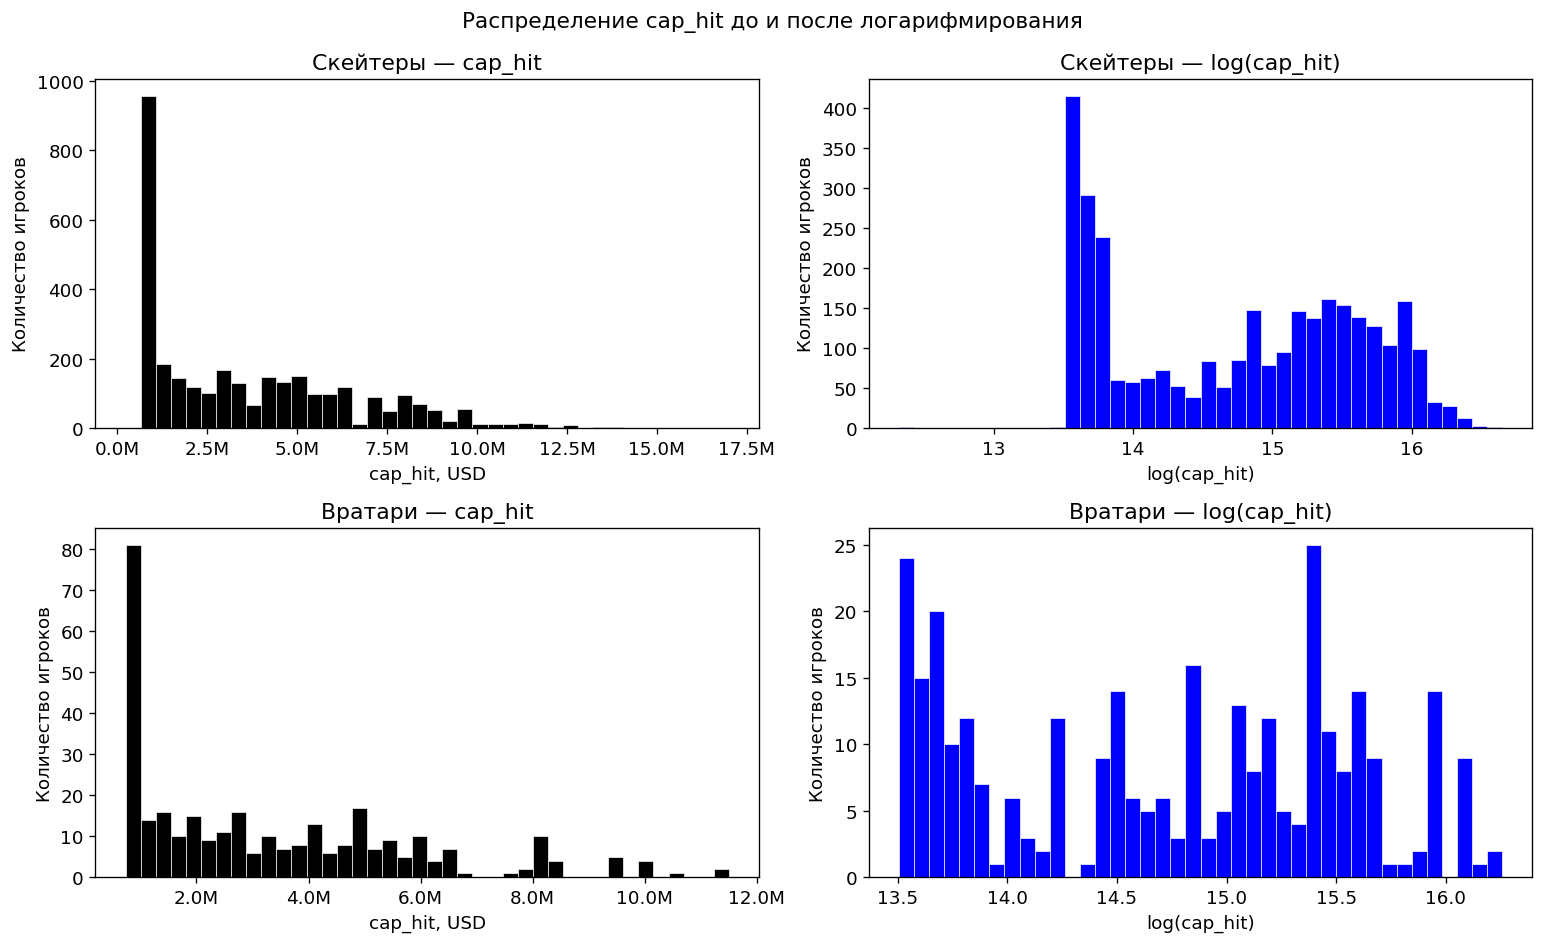

Скошенность cap_hit скейтеры: 0.90
Скошенность log(cap_hit) скейтеры: -0.01

Скошенность cap_hit вратари: 0.99
Скошенность log(cap_hit) вратари: -0.04


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for i, (df, label) in enumerate([(sk, "Скейтеры"), (go, "Вратари")]):
    data = df["cap_hit"].dropna()

    axes[i, 0].hist(data, bins=40, color="black", edgecolor="white", linewidth=0.4)
    axes[i, 0].set_title(f"{label} — cap_hit")
    axes[i, 0].set_xlabel("cap_hit, USD")
    axes[i, 0].set_ylabel("Количество игроков")
    axes[i, 0].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
    )

    axes[i, 1].hist(np.log1p(data), bins=40, color="blue", edgecolor="white", linewidth=0.4)
    axes[i, 1].set_title(f"{label} — log(cap_hit)")
    axes[i, 1].set_xlabel("log(cap_hit)")
    axes[i, 1].set_ylabel("Количество игроков")

plt.suptitle("Распределение cap_hit до и после логарифмирования", fontsize=13)
plt.tight_layout()
plt.savefig(root / "report/images/cap_hit_distribution.png", bbox_inches="tight")
plt.show()

print(f"Скошенность cap_hit скейтеры: {sk['cap_hit'].skew():.2f}")
print(f"Скошенность log(cap_hit) скейтеры: {np.log1p(sk['cap_hit'].dropna()).skew():.2f}")
print()
print(f"Скошенность cap_hit вратари: {go['cap_hit'].skew():.2f}")
print(f"Скошенность log(cap_hit) вратари: {np.log1p(go['cap_hit'].dropna()).skew():.2f}")

### Распределение cap_hit

После логарифмирования скошенность практически исчезает:

| | cap_hit skew | log(cap_hit) skew |
|---|---|---|
| Скейтеры | 0.90 | -0.01 |
| Вратари | 0.99 | -0.04 |

Скошенность 0.01–-0.04 после логарифма т.е. трансформация 
убирает асимметрию. **Вывод: в preprocessing и моделировании используем `log(cap_hit)`
как целевую переменную**

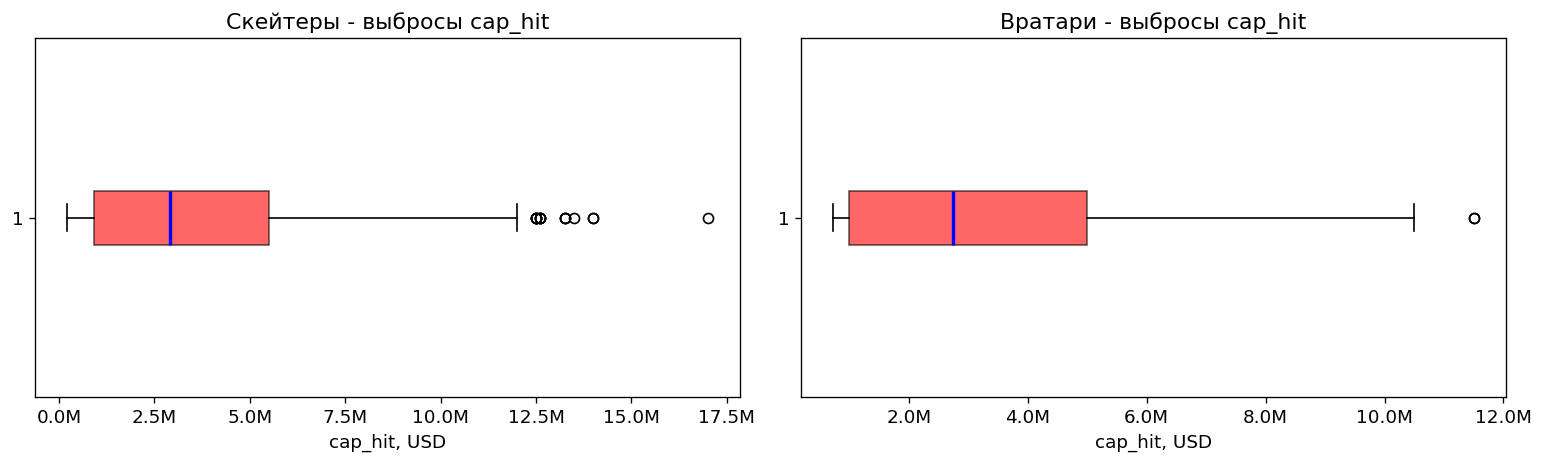

Топ-5 скейтеров по зарплате:
 skaterFullName  season_year    cap_hit  points
Kirill Kaprizov         2026 17000000.0      89
 Leon Draisaitl         2025 14000000.0     106
 Leon Draisaitl         2026 14000000.0      97
    Jack Eichel         2026 13500000.0      90
Auston Matthews         2024 13250000.0     107

Топ-5 вратарей по зарплате:
  goalieFullName  season_year    cap_hit  wins
 Igor Shesterkin         2025 11500000.0    27
 Igor Shesterkin         2026 11500000.0    25
     Carey Price         2022 10500000.0     1
Sergei Bobrovsky         2022 10000000.0    39
Sergei Bobrovsky         2023 10000000.0    24

Нижние 5 скейтеров по зарплате:
      skaterFullName  season_year  cap_hit  points
       Ville Heinola         2023 224000.0       1
         Matt Martin         2024 701963.0       8
     Hudson Fasching         2022 750000.0       0
Jaret Anderson-Dolan         2022 750000.0       0
          Mason Shaw         2022 750000.0       0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, (df, label) in enumerate([(sk, "Скейтеры"), (go, "Вратари")]):
    data = df["cap_hit"].dropna()
    axes[i].boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor="red", alpha=0.6),
                    medianprops=dict(color="blue", linewidth=2))
    axes[i].set_title(f"{label} - выбросы cap_hit")
    axes[i].set_xlabel("cap_hit, USD")
    axes[i].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
    )

plt.tight_layout()
plt.savefig(root / "report/images/cap_hit_boxplot.png", bbox_inches="tight")
plt.show()

print("Топ-5 скейтеров по зарплате:")
print(sk.nlargest(5, "cap_hit")[["skaterFullName", "season_year", "cap_hit", "points"]].to_string(index=False))
print()
print("Топ-5 вратарей по зарплате:")
print(go.nlargest(5, "cap_hit")[["goalieFullName", "season_year", "cap_hit", "wins"]].to_string(index=False))
print()
print("Нижние 5 скейтеров по зарплате:")
print(sk.nsmallest(5, "cap_hit")[["skaterFullName", "season_year", "cap_hit", "points"]].to_string(index=False))

### Выбросы cap_hit

На boxplot видны выбросы в верхней части - это суперзвёзды с контрактами 12M+.
У скейтеров 4 точки выше усов, у вратарей 1.

**Топ зарплат выглядят валидно** - это реальные топ-игроки лиги с соответствующей статистикой.
Carey Price в топе вратарей при 1 победе ь.к. он был травмирован весь сезон 2021-22,
но контракт продолжал считаться против потолка. Это реальная особенность NHL, а
не ошибка данных.

**Нижняя граница** - минимальный контракт NHL в эти сезоны составлял около 750K
(но Ville Heinola попал на 224K и это нетипично низкое значение, стоит проверить).

Выбросы в верхней части не удаляем т.к. топ-зарплаты являются частью задачи
предсказания. После логарифмирования их влияние на функцию потерь снижается естественным образом.

In [16]:
print("Проверка минимального значения cap_hit у скейтеров:")
print(sk[sk["cap_hit"] < 500000][["skaterFullName", "season_year", "cap_hit", "gamesPlayed", "teamAbbrevs"]])

Проверка минимального значения cap_hit у скейтеров:
     skaterFullName  season_year   cap_hit  gamesPlayed teamAbbrevs
1112  Ville Heinola         2023  224000.0           10         WPG


Spotrac мог подтянуть AHL-ставку вместо NHL cap hit. Это единственное такое значение в датасете,
удалять строку не будем, но в preprocessing можно поставить нижний порог
на уровне минимального контракта NHL и отфильтровать аномальные значения.

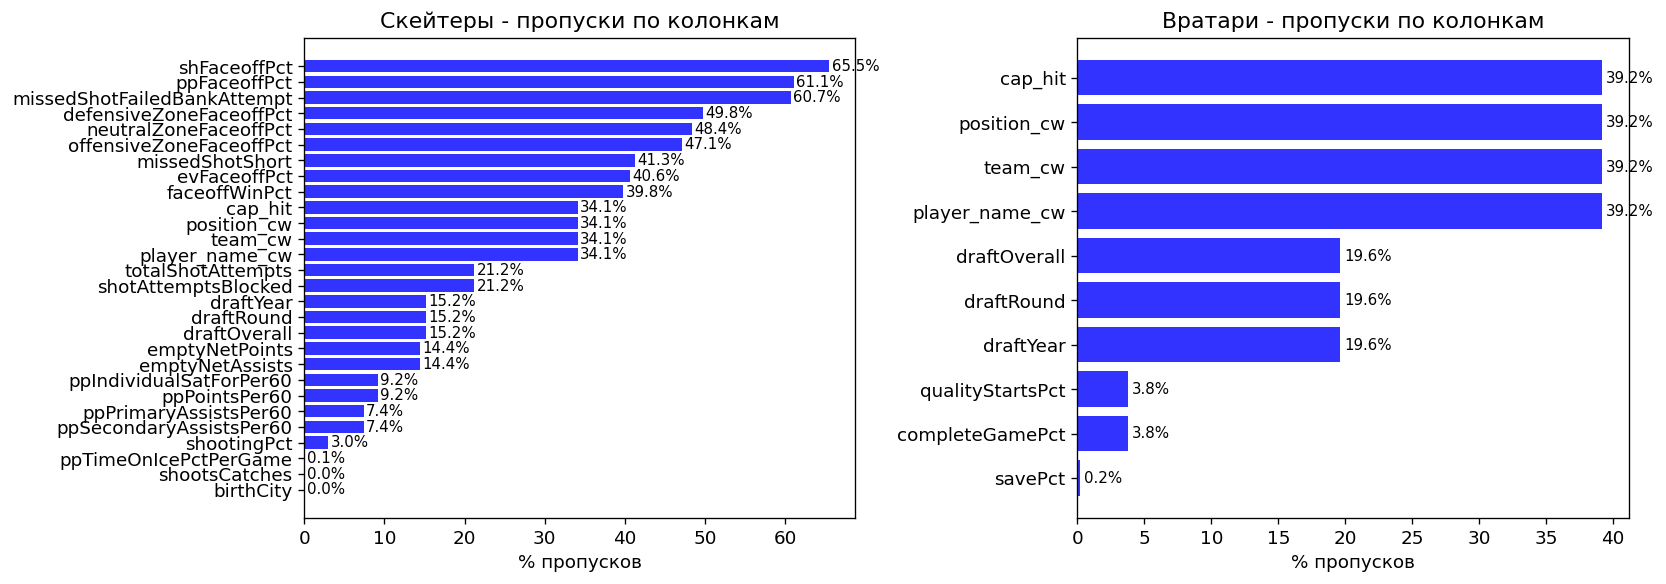

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (df, label, id_col) in enumerate([
    (sk, "Скейтеры", "skaterFullName"),
    (go, "Вратари", "goalieFullName")
]):
    missing = df.isnull().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    pct = (missing / len(df) * 100).round(1)

    axes[i].barh(missing.index[::-1], pct.values[::-1], color="blue", alpha=0.8)
    axes[i].set_title(f"{label} - пропуски по колонкам")
    axes[i].set_xlabel("% пропусков")
    for j, v in enumerate(pct.values[::-1]):
        axes[i].text(v + 0.3, j, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(root / "report/images/missing_values.png", bbox_inches="tight")
plt.show()

### Анализ пропусков

**Скейтеры**: три группы пропусков с разными причинами:

| Группа | Колонки | % | Причина | Решение |
|---|---|---|---|---|
| Вбрасывания | `shFaceoffPct`, `ppFaceoffPct` и др. | 40–66% | Не-центры не участвуют во вбрасываниях | Заполнить 0 |
| Пустые ворота / промахи | `missedShotFailedBankAttempt`, `missedShotShort` | 41–61% | Отсутствуют у игроков с малым льдом, старый API | Заполнить 0 |
| Таргет + Spotrac | `cap_hit`, `player_name_cw`, `team_cw`, `position_cw` | 34.1% | Игроки без NHL-контракта или не найденные при джоине | Дропнуть строки (таргет), удалить колонки |
| Corsi | `totalShotAttempts`, `shotAttemptsBlocked` | 21.2% | Сезон 2021-22, старый API не отдавал эти данные | Заполнить 0 |
| Драфт | `draftYear`, `draftRound`, `draftOverall` | 15.2% | Игроки подписаны как свободные агенты, не задрафтованы | Заполнить штрафным значением + флаг `is_undrafted` |
| pp per-60 | `ppPrimaryAssistsPer60` и др. | 7–9% | Игроки без времени в большинстве | Заполнить 0 |

**Вратари**: структура проще:

| Группа | % | Причина | Решение |
|---|---|---|---|
| Таргет + Spotrac | 39.2% | Аналогично скейтерам | Дропнуть / удалить |
| Драфт | 19.6% | Недрафтованные вратари | Заполнить штрафным + флаг |
| `qualityStartsPct`, `completeGamePct` | 3.8% | 0 стартов в отдельных играх | Заполнить 0 |
| `savePct` | 0.2% | заполнить медианой | Медиана |

Пропуски в `cap_hit` не случайные, это систематическое
отсутствие данных у игроков на двусторонних контрактах и тех, кого не удалось
найти при джоине по имени. Такие строки дропаются, не заполняются.

In [19]:
print("Пропуски cap_hit по сезонам (скейтеры):")
print(sk.groupby("season_year")["cap_hit"].apply(
    lambda x: f"{x.isna().sum()} из {len(x)} ({x.isna().mean():.1%})"
))

print()
print("Пропуски cap_hit по позициям (скейтеры):")
print(sk.groupby("positionCode")["cap_hit"].apply(
    lambda x: f"{x.isna().sum()} из {len(x)} ({x.isna().mean():.1%})"
))

print()
print("Распределение gamesPlayed у игроков БЕЗ cap_hit (скейтеры):")
print(sk[sk["cap_hit"].isna()]["gamesPlayed"].describe().round(1))
print()
print("Распределение gamesPlayed у игроков С cap_hit (скейтеры):")
print(sk[sk["cap_hit"].notna()]["gamesPlayed"].describe().round(1))

Пропуски cap_hit по сезонам (скейтеры):
season_year
2022    340 из 1006 (33.8%)
2023     313 из 953 (32.8%)
2024     264 из 925 (28.5%)
2025     265 из 922 (28.7%)
2026     438 из 942 (46.5%)
Name: cap_hit, dtype: str

Пропуски cap_hit по позициям (скейтеры):
positionCode
C    488 из 1487 (32.8%)
D    542 из 1639 (33.1%)
L     315 из 885 (35.6%)
R     275 из 737 (37.3%)
Name: cap_hit, dtype: str

Распределение gamesPlayed у игроков БЕЗ cap_hit (скейтеры):
count    1620.0
mean       28.3
std        27.2
min         1.0
25%         4.0
50%        17.0
75%        51.0
max        84.0
Name: gamesPlayed, dtype: float64

Распределение gamesPlayed у игроков С cap_hit (скейтеры):
count    3128.0
mean       61.0
std        23.7
min         1.0
25%        51.0
50%        71.0
75%        79.0
max        85.0
Name: gamesPlayed, dtype: float64


### Характер пропусков в cap_hit

**По сезонам:** процент пропусков стабилен на уровне 29–34% для сезонов 2022–2025.
Резкий скачок до 46.5% в сезоне 2026 объясняется тем, что сезон ещё не завершён
на момент сбора данных, многие контракты не были опубликованы на Spotrac.

**По позициям:** пропуски распределены равномерно по всем позициям,
значит пропуски не связаны с позицией игрока.

**По играм**
Игроки без зарплаты сыграли в среднем вдвое меньше матчей т.к. это AHL-callup игроки
на двусторонних контрактах, которые провели несколько игр в NHL, но основной
контракт у них в AHL. Их cap hit не является NHL-зарплатой в полном смысле.

**Итоговый вывод по пропускам:** пропуски в `cap_hit` системные и содержательные,
не случайные. Стратегия - дропать, не заполнять. Фильтр `gamesPlayed >= 10`
дополнительно

In [20]:
print("Числа для preprocessing:")
print()

max_draft = sk["draftOverall"].max()
print(f"Максимальный номер пика на драфте (скейтеры): {max_draft}")
print(f"Штрафное значение для недрафтованных: {int(max_draft) + 50}")

print()
svpct_mean = go["savePct"].mean()
svpct_median = go["savePct"].median()
print(f"savePct вратари, среднее: {svpct_mean:.4f}")
print(f"savePct вратари, медиана: {svpct_median:.4f}")
print()
print(go["savePct"].describe().round(4))

Числа для preprocessing:

Максимальный номер пика на драфте (скейтеры): 36.0
Штрафное значение для недрафтованных: 86

savePct вратари, среднее: 0.8933
savePct вратари, медиана: 0.8994

count    524.0000
mean       0.8933
std        0.0421
min        0.5000
25%        0.8858
50%        0.8994
75%        0.9107
max        1.0000
Name: savePct, dtype: float64


Колонка `draftOverall` содержит номер пика внутри раунда (1–36),
а не общий номер пика по драфту (1–225). 

Для корректной оценки ценности игрока нужно учитывать оба параметра: раунд и
номер внутри раунда. Штрафное значение для недрафтованных:
максимум внутри раунда = 36, штрафное значение = 36 + 10 = 46.

Также в preprocessing нужно добавить комбинированный признак:
`draft_value = (draftRound - 1) * 36 + draftOverall`
который даёт приближение к реальному overall pick.
Недрафтованным присваиваем максимально возможное значение.

In [22]:
max_round = sk["draftRound"].max()
max_pick = sk["draftOverall"].max()
max_draft_value = (max_round - 1) * max_pick + max_pick

print(f"Максимальный раунд драфта: {max_round}")
print(f"Максимальный пик внутри раунда: {max_pick}")
print(f"Максимальный расчётный draft_value: {max_draft_value}")
print(f"Штрафное значение для недрафтованных: {int(max_draft_value) + 50}")

print()
print("Примеры расчёта draft_value:")
sample = sk[sk["draftRound"].notna()][["skaterFullName", "draftRound", "draftOverall"]].head(8).copy()
sample["draft_value"] = (sample["draftRound"] - 1) * max_pick + sample["draftOverall"]
print(sample.to_string(index=False))

Максимальный раунд драфта: 7.0
Максимальный пик внутри раунда: 36.0
Максимальный расчётный draft_value: 252.0
Штрафное значение для недрафтованных: 302

Примеры расчёта draft_value:
  skaterFullName  draftRound  draftOverall  draft_value
   Cole Schwindt         3.0          19.0         91.0
 Tyler Lewington         7.0          23.0        239.0
      Joey Keane         3.0          26.0         98.0
     Martin Kaut         1.0          16.0         16.0
 Anthony Angello         5.0          25.0        169.0
   Alex Turcotte         1.0           5.0          5.0
 Pavel Dorofeyev         3.0          17.0         89.0
Dmitri Samorukov         3.0          22.0         94.0


## Выводы первой части EDA

### Принятые решения для preprocessing.py

**Таргет:**
- Распределение `cap_hit` скошено вправо 
- После логарифмирования skew падает значит используем `log(cap_hit)` как таргет
- При оценке качества моделей переводим обратно

**Пропуски:**
- `cap_hit` - дропаем строки
- Вбрасывания, pp, пустые ворота, Corsi - заполняем 0
- Драфт - заполняем расчётным максимумом 302 + флаг `is_undrafted`
- `savePct` вратари, заполняем медианой

**Выбросы:**
- Верхние выбросы (топ-контракты) валидны, не удаляем
- 224K - аномальное значение, добавляем нижний порог